# Exploring MPI-FAUST Dataset

This notebook explores the MPI-FAUST 3D mesh dataset used for the POC.
It demonstrates:
- Loading PLY files from the dataset
- Visualizing 3D point clouds
- Understanding data structure and statistics

**Note:** This is an exploratory notebook. The main pipeline is in `mmidnet_pipeline.ipynb`.


In [2]:
import numpy as np
import matplotlib.pyplot as plt
from mpl_toolkits.mplot3d import Axes3D
import os
import glob

# Try importing mesh loading libraries
try:
    import trimesh
    HAS_TRIMESH = True
except ImportError:
    HAS_TRIMESH = False
    print("trimesh not available, will try plyfile")

try:
    from plyfile import PlyData
    HAS_PLYFILE = True
except ImportError:
    HAS_PLYFILE = False
    print("plyfile not available")

print(f"trimesh: {HAS_TRIMESH}, plyfile: {HAS_PLYFILE}")


trimesh: True, plyfile: True


## 1. Check Dataset Structure


In [3]:
# Dataset paths
base_dir = 'MPI-FAUST'
training_dir = os.path.join(base_dir, 'training')
scans_dir = os.path.join(training_dir, 'scans')

print(f"Base directory: {base_dir}")
print(f"Training directory exists: {os.path.exists(training_dir)}")
print(f"Scans directory exists: {os.path.exists(scans_dir)}")

# List some PLY files
if os.path.exists(scans_dir):
    ply_files = sorted(glob.glob(os.path.join(scans_dir, '*.ply')))
    print(f"\nFound {len(ply_files)} PLY files")
    print(f"\nFirst 5 files:")
    for f in ply_files[:5]:
        print(f"  {os.path.basename(f)}")
    print(f"\nLast 5 files:")
    for f in ply_files[-5:]:
        print(f"  {os.path.basename(f)}")


Base directory: MPI-FAUST
Training directory exists: True
Scans directory exists: True

Found 100 PLY files

First 5 files:
  tr_scan_000.ply
  tr_scan_001.ply
  tr_scan_002.ply
  tr_scan_003.ply
  tr_scan_004.ply

Last 5 files:
  tr_scan_095.ply
  tr_scan_096.ply
  tr_scan_097.ply
  tr_scan_098.ply
  tr_scan_099.ply


## 2. Load a PLY File


In [4]:
def load_ply_file(ply_path):
    """Load PLY file and return vertices and faces"""
    if HAS_TRIMESH:
        try:
            mesh = trimesh.load(ply_path)
            vertices = np.array(mesh.vertices)
            if hasattr(mesh, 'faces') and len(mesh.faces) > 0:
                faces = np.array(mesh.faces)
            else:
                faces = None
            return vertices, faces, 'trimesh'
        except Exception as e:
            print(f"trimesh failed: {e}")
    
    if HAS_PLYFILE:
        try:
            plydata = PlyData.read(ply_path)
            vertices = np.array([list(v) for v in plydata['vertex']])
            if 'face' in plydata:
                faces = np.array([list(f)[0] for f in plydata['face']])
            else:
                faces = None
            return vertices, faces, 'plyfile'
        except Exception as e:
            print(f"plyfile failed: {e}")
    
    raise ValueError("Could not load PLY file with available libraries")

# Load first scan
if os.path.exists(scans_dir):
    test_file = os.path.join(scans_dir, 'tr_scan_000.ply')
    if os.path.exists(test_file):
        print(f"Loading: {os.path.basename(test_file)}")
        vertices, faces, loader_used = load_ply_file(test_file)
        print(f"\nLoaded using: {loader_used}")
        print(f"Vertices shape: {vertices.shape}")
        print(f"Vertices range:")
        print(f"  X: [{vertices[:, 0].min():.2f}, {vertices[:, 0].max():.2f}]")
        print(f"  Y: [{vertices[:, 1].min():.2f}, {vertices[:, 1].max():.2f}]")
        print(f"  Z: [{vertices[:, 2].min():.2f}, {vertices[:, 2].max():.2f}]")
        if faces is not None:
            print(f"Faces shape: {faces.shape}")
        else:
            print("No faces found (point cloud only)")


Loading: tr_scan_000.ply

Loaded using: trimesh
Vertices shape: (176185, 3)
Vertices range:
  X: [-0.37, 0.43]
  Y: [-1.16, 0.62]
  Z: [-0.08, 0.32]
Faces shape: (352169, 3)


## 3. Visualize Point Clouds


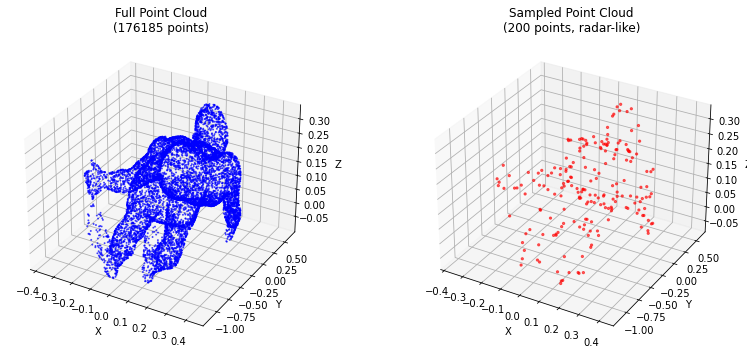

In [5]:
def plot_point_cloud(vertices, title="Point Cloud", ax=None, color='blue', alpha=0.6, s=1):
    """Plot 3D point cloud"""
    if ax is None:
        fig = plt.figure(figsize=(10, 8))
        ax = fig.add_subplot(111, projection='3d')
    
    # Sample points if too many (for faster visualization)
    if len(vertices) > 10000:
        indices = np.random.choice(len(vertices), 10000, replace=False)
        vertices_plot = vertices[indices]
    else:
        vertices_plot = vertices
    
    ax.scatter(vertices_plot[:, 0], vertices_plot[:, 1], vertices_plot[:, 2], 
               c=color, alpha=alpha, s=s)
    ax.set_xlabel('X')
    ax.set_ylabel('Y')
    ax.set_zlabel('Z')
    ax.set_title(title)
    
    return ax

# Plot first scan
if 'vertices' in locals():
    fig = plt.figure(figsize=(12, 5))
    
    # Full point cloud
    ax1 = fig.add_subplot(121, projection='3d')
    plot_point_cloud(vertices, title=f"Full Point Cloud\n({len(vertices)} points)", ax=ax1)
    
    # Sampled point cloud (simulating radar-like sparse data)
    if len(vertices) > 200:
        sampled_indices = np.random.choice(len(vertices), 200, replace=False)
        sampled_vertices = vertices[sampled_indices]
    else:
        sampled_vertices = vertices
    
    ax2 = fig.add_subplot(122, projection='3d')
    plot_point_cloud(sampled_vertices, title=f"Sampled Point Cloud\n({len(sampled_vertices)} points, radar-like)", 
                     ax=ax2, color='red', s=5)
    
    plt.tight_layout()
    plt.show()


## 4. Load Multiple Scans from Different Subjects


In [6]:
# Load a few scans from different subjects
# Assuming 10 scans per subject (0-9, 10-19, etc.)
scan_indices = [0, 10, 20, 30, 40]  # One from each of first 5 subjects

scans_data = []
for idx in scan_indices:
    ply_file = os.path.join(scans_dir, f'tr_scan_{idx:03d}.ply')
    if os.path.exists(ply_file):
        vertices, faces, _ = load_ply_file(ply_file)
        # Sample 200 points (simulating radar data)
        if len(vertices) > 200:
            sampled = vertices[np.random.choice(len(vertices), 200, replace=False)]
        else:
            sampled = vertices
        scans_data.append({
            'index': idx,
            'subject': idx // 10,  # Assuming 10 scans per subject
            'vertices': sampled,
            'original_count': len(vertices)
        })
        print(f"Loaded scan {idx:03d} (subject {idx//10}): {len(vertices)} vertices -> {len(sampled)} sampled")

print(f"\nLoaded {len(scans_data)} scans")


Loaded scan 000 (subject 0): 176185 vertices -> 200 sampled
Loaded scan 010 (subject 1): 166926 vertices -> 200 sampled
Loaded scan 020 (subject 2): 190990 vertices -> 200 sampled
Loaded scan 030 (subject 3): 206644 vertices -> 200 sampled
Loaded scan 040 (subject 4): 161641 vertices -> 200 sampled

Loaded 5 scans


## 5. Visualize Multiple Scans


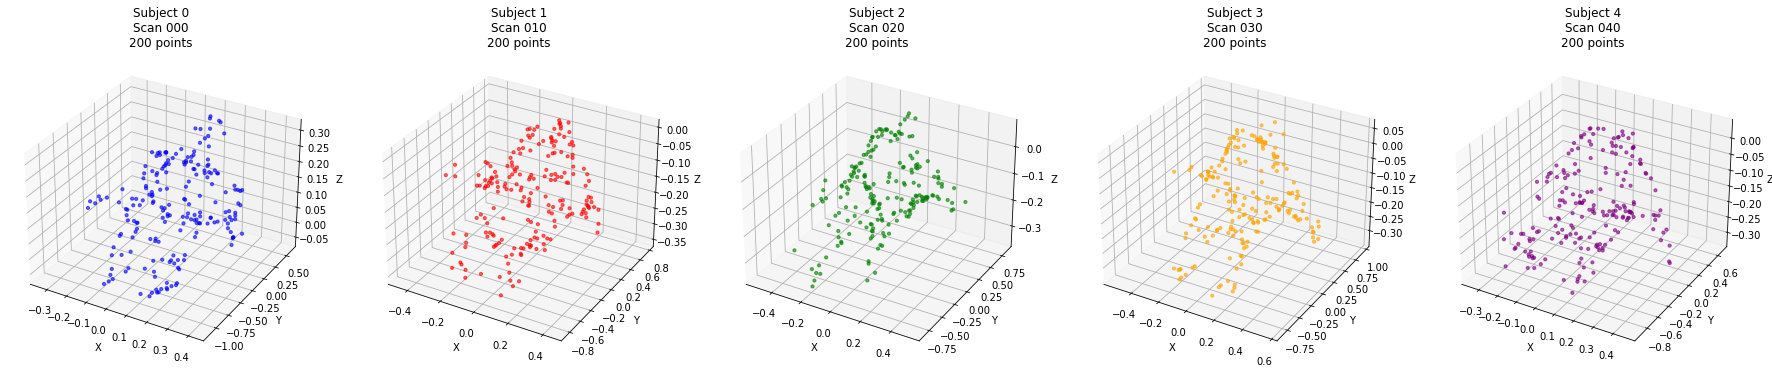

In [7]:
# Plot multiple scans side by side
if len(scans_data) > 0:
    n_scans = len(scans_data)
    fig = plt.figure(figsize=(5*n_scans, 5))
    
    colors = ['blue', 'red', 'green', 'orange', 'purple']
    
    for i, scan in enumerate(scans_data):
        ax = fig.add_subplot(1, n_scans, i+1, projection='3d')
        plot_point_cloud(
            scan['vertices'], 
            title=f"Subject {scan['subject']}\nScan {scan['index']:03d}\n{len(scan['vertices'])} points",
            ax=ax, 
            color=colors[i % len(colors)],
            s=10
        )
    
    plt.tight_layout()
    plt.show()


## 6. Compare Scans from Same Subject


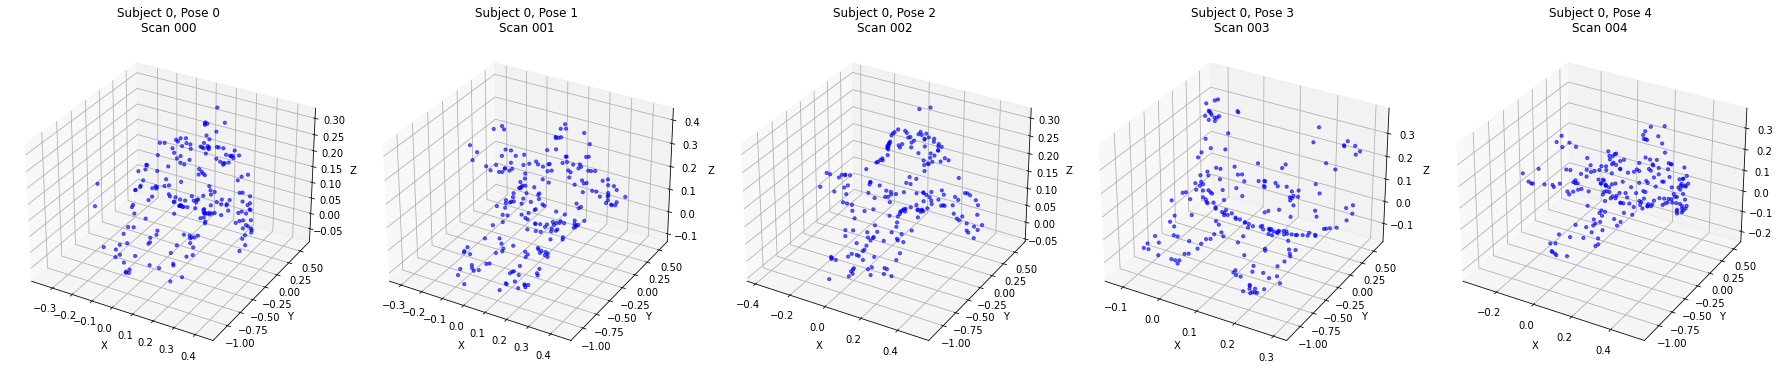

In [8]:
# Load multiple scans from the same subject (subject 0)
subject_0_scans = [0, 1, 2, 3, 4]  # First 5 scans from subject 0

same_subject_data = []
for idx in subject_0_scans:
    ply_file = os.path.join(scans_dir, f'tr_scan_{idx:03d}.ply')
    if os.path.exists(ply_file):
        vertices, faces, _ = load_ply_file(ply_file)
        # Sample 200 points
        if len(vertices) > 200:
            sampled = vertices[np.random.choice(len(vertices), 200, replace=False)]
        else:
            sampled = vertices
        same_subject_data.append({
            'index': idx,
            'vertices': sampled
        })

# Plot same subject, different poses
if len(same_subject_data) > 0:
    n_scans = len(same_subject_data)
    fig = plt.figure(figsize=(5*n_scans, 5))
    
    for i, scan in enumerate(same_subject_data):
        ax = fig.add_subplot(1, n_scans, i+1, projection='3d')
        plot_point_cloud(
            scan['vertices'], 
            title=f"Subject 0, Pose {i}\nScan {scan['index']:03d}",
            ax=ax, 
            color='blue',
            s=10
        )
    
    plt.tight_layout()
    plt.show()


## 7. Statistics Summary


Analyzing 100 files...

Vertex Statistics (from 100 scans):
  Min: 141784
  Max: 217228
  Mean: 177152
  Median: 176076

Face Statistics (from 100 scans):
  Min: 283217
  Max: 434320
  Mean: 354172
  Median: 352022


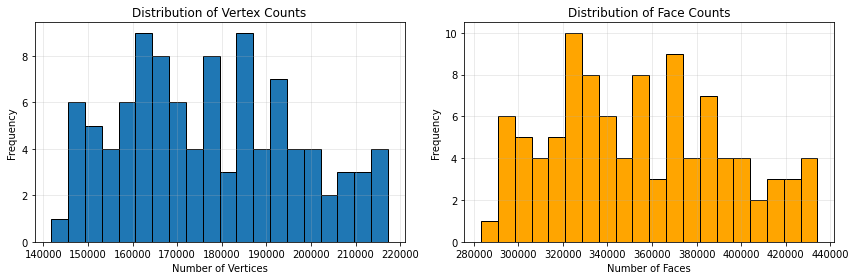

In [12]:
# Collect statistics from all scans
if os.path.exists(scans_dir):
    ply_files = sorted(glob.glob(os.path.join(scans_dir, '*.ply')))
    
    vertex_counts = []
    face_counts = []
    
    print(f"Analyzing {len(ply_files)} files...")
    
    for i, ply_file in enumerate(ply_files): 
        try:
            vertices, faces, _ = load_ply_file(ply_file)
            vertex_counts.append(len(vertices))
            if faces is not None:
                face_counts.append(len(faces))
        except Exception as e:
            print(f"Error loading {os.path.basename(ply_file)}: {e}")
    
    if vertex_counts:
        print(f"\nVertex Statistics (from {len(vertex_counts)} scans):")
        print(f"  Min: {min(vertex_counts)}")
        print(f"  Max: {max(vertex_counts)}")
        print(f"  Mean: {np.mean(vertex_counts):.0f}")
        print(f"  Median: {np.median(vertex_counts):.0f}")
        
        if face_counts:
            print(f"\nFace Statistics (from {len(face_counts)} scans):")
            print(f"  Min: {min(face_counts)}")
            print(f"  Max: {max(face_counts)}")
            print(f"  Mean: {np.mean(face_counts):.0f}")
            print(f"  Median: {np.median(face_counts):.0f}")
        
        # Plot distribution
        fig, axes = plt.subplots(1, 2, figsize=(12, 4))
        
        axes[0].hist(vertex_counts, bins=20, edgecolor='black')
        axes[0].set_xlabel('Number of Vertices')
        axes[0].set_ylabel('Frequency')
        axes[0].set_title('Distribution of Vertex Counts')
        axes[0].grid(True, alpha=0.3)
        
        if face_counts:
            axes[1].hist(face_counts, bins=20, edgecolor='black', color='orange')
            axes[1].set_xlabel('Number of Faces')
            axes[1].set_ylabel('Frequency')
            axes[1].set_title('Distribution of Face Counts')
            axes[1].grid(True, alpha=0.3)
        
        plt.tight_layout()
        plt.show()


## 8. Understanding Subject Labels

The MPI-FAUST dataset has **10 subjects** with **10 scans each** (100 total training scans).
The subject labels are **inferred from the scan numbering**:
- Scans 0-9 → Subject 0
- Scans 10-19 → Subject 1
- Scans 20-29 → Subject 2
- ... and so on

**Formula**: `subject_id = scan_index // 10`


In [10]:
# Create subject labels mapping
def get_subject_label(scan_index):
    """Get subject ID from scan index"""
    return scan_index // 10

# Verify the mapping
if os.path.exists(scans_dir):
    ply_files = sorted(glob.glob(os.path.join(scans_dir, '*.ply')))
    
    print("Subject Label Mapping:")
    print("=" * 50)
    print(f"{'Scan Index':<15} {'Subject ID':<15} {'Filename'}")
    print("-" * 50)
    
    # Show examples from each subject
    for subject_id in range(10):
        scan_idx = subject_id * 10
        filename = f'tr_scan_{scan_idx:03d}.ply'
        print(f"{scan_idx:<15} {subject_id:<15} {filename}")
    
    print("\n" + "=" * 50)
    print(f"Total scans: {len(ply_files)}")
    print(f"Total subjects: 10")
    print(f"Scans per subject: 10")
    
    # Create a full mapping
    scan_to_subject = {}
    for ply_file in ply_files:
        scan_index = int(os.path.basename(ply_file).split('_')[2].split('.')[0])
        subject_id = get_subject_label(scan_index)
        scan_to_subject[scan_index] = subject_id
    
    # Verify distribution
    print("\nSubject Distribution:")
    print("-" * 30)
    for subject_id in range(10):
        count = sum(1 for s, subj in scan_to_subject.items() if subj == subject_id)
        print(f"Subject {subject_id}: {count} scans")


Subject Label Mapping:
Scan Index      Subject ID      Filename
--------------------------------------------------
0               0               tr_scan_000.ply
10              1               tr_scan_010.ply
20              2               tr_scan_020.ply
30              3               tr_scan_030.ply
40              4               tr_scan_040.ply
50              5               tr_scan_050.ply
60              6               tr_scan_060.ply
70              7               tr_scan_070.ply
80              8               tr_scan_080.ply
90              9               tr_scan_090.ply

Total scans: 100
Total subjects: 10
Scans per subject: 10

Subject Distribution:
------------------------------
Subject 0: 10 scans
Subject 1: 10 scans
Subject 2: 10 scans
Subject 3: 10 scans
Subject 4: 10 scans
Subject 5: 10 scans
Subject 6: 10 scans
Subject 7: 10 scans
Subject 8: 10 scans
Subject 9: 10 scans


## 9. Visualize Scans with Subject Labels


<ipython-input-5-9fd00e04d09a>:14: UserWarning: *c* argument looks like a single numeric RGB or RGBA sequence, which should be avoided as value-mapping will have precedence in case its length matches with *x* & *y*.  Please use the *color* keyword-argument or provide a 2D array with a single row if you intend to specify the same RGB or RGBA value for all points.
  ax.scatter(vertices_plot[:, 0], vertices_plot[:, 1], vertices_plot[:, 2],


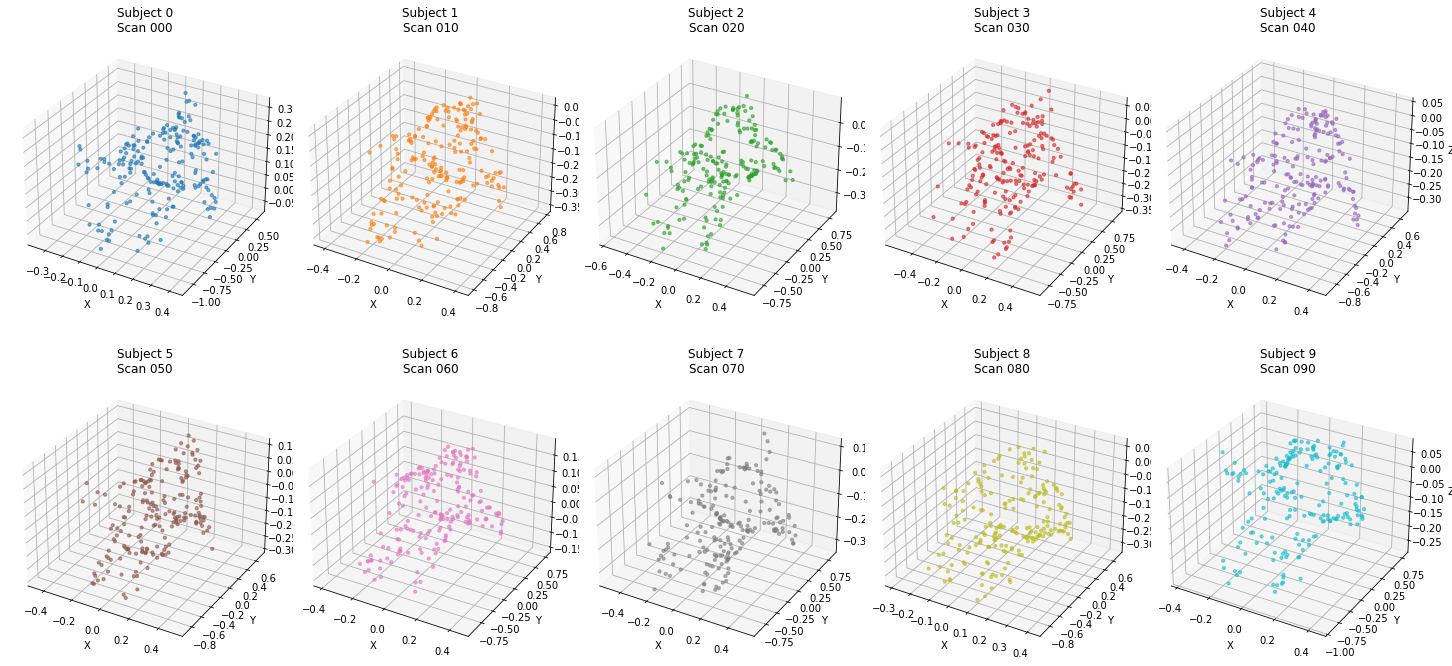


Loaded and visualized 10 subjects


In [11]:
# Load and visualize scans with their subject labels
if os.path.exists(scans_dir):
    # Load one scan from each subject
    subject_scans = []
    for subject_id in range(10):
        scan_idx = subject_id * 10  # First scan from each subject
        ply_file = os.path.join(scans_dir, f'tr_scan_{scan_idx:03d}.ply')
        if os.path.exists(ply_file):
            vertices, faces, _ = load_ply_file(ply_file)
            # Sample 200 points
            if len(vertices) > 200:
                sampled = vertices[np.random.choice(len(vertices), 200, replace=False)]
            else:
                sampled = vertices
            subject_scans.append({
                'scan_index': scan_idx,
                'subject_id': subject_id,
                'vertices': sampled
            })
    
    # Plot all 10 subjects in a grid
    if len(subject_scans) > 0:
        fig = plt.figure(figsize=(20, 10))
        
        # Create a 2x5 grid
        for i, scan in enumerate(subject_scans):
            ax = fig.add_subplot(2, 5, i+1, projection='3d')
            plot_point_cloud(
                scan['vertices'],
                title=f"Subject {scan['subject_id']}\nScan {scan['scan_index']:03d}",
                ax=ax,
                color=plt.cm.tab10(i),
                s=10
            )
        
        plt.tight_layout()
        plt.show()
        
        print(f"\nLoaded and visualized {len(subject_scans)} subjects")
